**Step 1 : Download Dataset and Understand the Columns**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
355417,17,CASH_OUT,146243.29,C348667420,1056.48,0.00,C912252532,2854519.47,3000762.75,0.0,0.0
355418,17,CASH_OUT,156205.32,C409605278,158.00,0.00,C1832841021,537006.83,693212.15,0.0,0.0
355419,17,CASH_OUT,1880.13,C1526906281,156.00,0.00,C285163095,197804.46,199684.59,0.0,0.0
355420,17,CASH_IN,23186.64,C699805358,0.00,23186.64,C241104317,907714.51,884527.86,0.0,0.0


In [10]:
df[df['isFlaggedFraud'] == 1.0]['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,


In [12]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,355422.000000,3.554220e+05,3.554220e+05,3.554210e+05,3.554210e+05,3.554210e+05,355421.000000,355421.0
mean,12.156546,1.744762e+05,8.909430e+05,9.101466e+05,9.840910e+05,1.191188e+06,0.000554,0.0
std,2.947187,2.920235e+05,2.912430e+06,2.949534e+06,2.366426e+06,2.573395e+06,0.023536,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,10.000000,1.317487e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,12.000000,8.048926e+04,1.776850e+04,0.000000e+00,9.965770e+04,2.072690e+05,0.000000,0.0
75%,15.000000,2.316858e+05,1.746710e+05,2.154246e+05,8.755708e+05,1.232563e+06,0.000000,0.0
max,17.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.138365e+07,4.148270e+07,1.000000,0.0


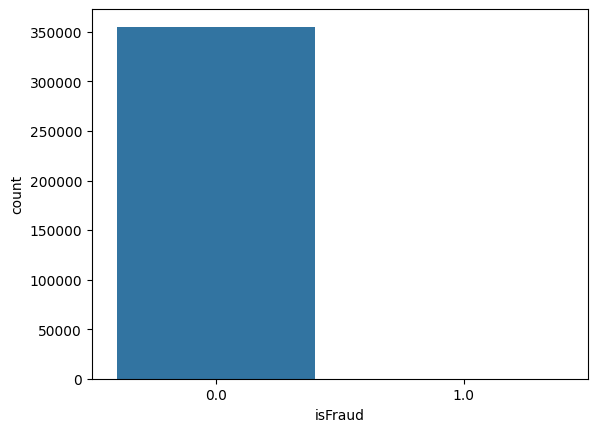

In [13]:
#plot the isFraud
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='isFraud', data=df)
plt.show()

In [14]:
#show number of fraud vs number of not fraud
df['isFraud'].value_counts()

,count
isFraud,
0.0,355224
1.0,197


In [15]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [16]:
#drop the null values since it is neglidible 1 only
df.dropna(inplace=True)

In [18]:
df.shape

(355421, 11)

In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [23]:
#find which colums are int , object , float and write down the names
int_col = [col for col in df.columns if df[col].dtype == 'int64']
float_col = [col for col in df.columns if df[col].dtype == 'float64']
object_col = [col for col in df.columns if df[col].dtype == 'object']

object_col

['type', 'nameOrig', 'nameDest']

In [24]:
df.duplicated().sum()

np.int64(0)

In [28]:
df["isFraud"].value_counts(normalize=True) * 100 #The dataset is highly imbalanced because fraud transactions are much fewer than normal transactions.

,proportion
isFraud,
0.0,99.944573
1.0,0.055427


In [29]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,355421


In [30]:
pd.crosstab(df["isFraud"], df["isFlaggedFraud"])

isFlaggedFraud,0.0
isFraud,
0.0,355224
1.0,197


In [31]:
df["type"].value_counts()

,count
type,
CASH_OUT,126720
PAYMENT,120696
CASH_IN,75827
TRANSFER,29614
DEBIT,2564


In [32]:
df.groupby("type")["isFraud"].sum().sort_values(ascending=False)

,isFraud
type,
CASH_OUT,101.0
TRANSFER,96.0
CASH_IN,0.0
DEBIT,0.0
PAYMENT,0.0


In [33]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0.0,355224.0,174156.797291,2.896284e+05,0.3,13172.735,80479.725,231627.78,6419835.27
1.0,197.0,750186.830812,1.509184e+06,119.0,18627.020,93810.760,747282.40,10000000.00


In [35]:
df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

df[["amount", "oldbalanceOrg", "newbalanceOrig", "orig_balance_diff"]].head()

,amount,oldbalanceOrg,newbalanceOrig,orig_balance_diff
0,9839.64,170136.0,160296.36,9839.64
1,1864.28,21249.0,19384.72,1864.28
2,181.00,181.0,0.00,181.00
3,181.00,181.0,0.00,181.00
4,11668.14,41554.0,29885.86,11668.14


In [36]:
df.groupby("isFraud")[["amount", "orig_balance_diff", "dest_balance_diff"]].mean()

,amount,orig_balance_diff,dest_balance_diff
isFraud,,,
0.0,174156.797291,-19613.669726,206935.336881
1.0,750186.830812,724697.362284,498032.733503


In [38]:
df["nameOrig"].nunique()
df["nameDest"].nunique()
df["nameOrig"].value_counts().head()
df["nameDest"].value_counts().head()

,count
nameDest,
C1286084959,86
C985934102,85
C248609774,83
C665576141,80
C2083562754,79


In [39]:
df[df["isFraud"] == 1]["type"].value_counts()

,count
type,
CASH_OUT,101
TRANSFER,96


In [40]:
df["isFlaggedFraud"].unique()

array([0.])

The column isFlaggedFraud contains only zero values, meaning the existing rule-based fraud flag did not identify any transaction as fraudulent. Therefore, this column was removed from the model training process.

In [41]:
df = df.drop(columns=["isFlaggedFraud"])

# **Step 2 :EDA**

1. Fraud vs non-fraud count
2. Fraud percentage
3. Transaction type distribution
4. Fraud count by transaction type
5. Fraud rate by transaction type
6. Amount analysis for fraud vs non-fraud
7. Balance difference analysis
8. Zero balance after transaction analysis
9. Amount equals old balance analysis
10. Amount-to-balance ratio analysis
11. Fraud over time
12. Sender and receiver analysis
13. Correlation analysis

In [43]:
fraud_counts = df["isFraud"].value_counts()
fraud_percent = df["isFraud"].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_percent)

isFraud
0.0    355224
1.0       197
Name: count, dtype: int64
isFraud
0.0    99.944573
1.0     0.055427
Name: proportion, dtype: float64


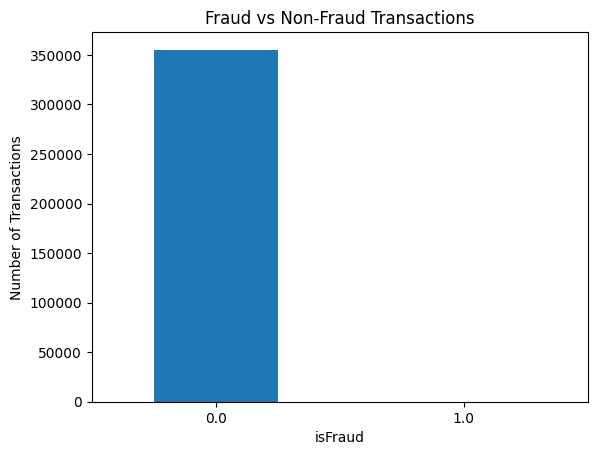

In [44]:
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

The dataset is highly imbalanced because non-fraud transactions are much higher than fraud transactions. Therefore, accuracy alone will not be a good evaluation metric.

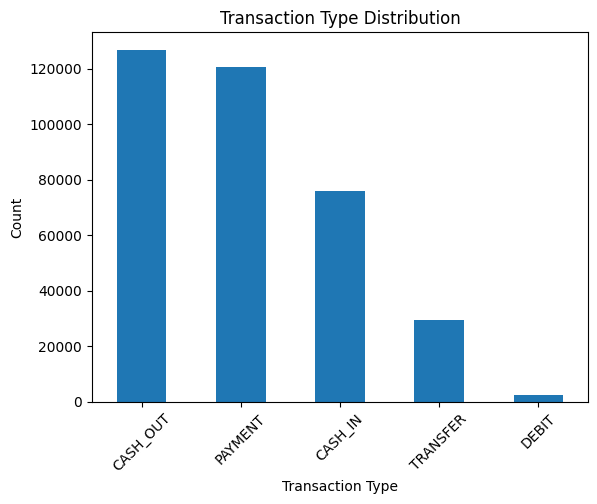

In [45]:
df["type"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [46]:
fraud_by_type = df.groupby("type")["isFraud"].agg(
    total_transactions="count",
    fraud_transactions="sum"
)

fraud_by_type["fraud_rate_percent"] = (
    fraud_by_type["fraud_transactions"] / fraud_by_type["total_transactions"]
) * 100

fraud_by_type.sort_values("fraud_transactions", ascending=False)

,total_transactions,fraud_transactions,fraud_rate_percent
type,,,
CASH_OUT,126720,101.0,0.079703
TRANSFER,29614,96.0,0.324171
CASH_IN,75827,0.0,0.000000
DEBIT,2564,0.0,0.000000
PAYMENT,120696,0.0,0.000000


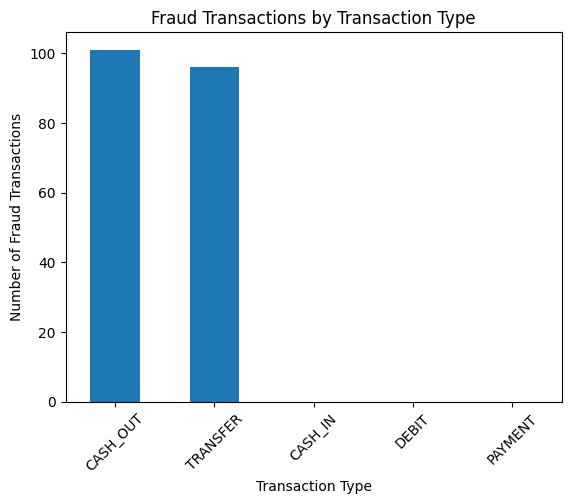

In [47]:
fraud_by_type["fraud_transactions"].sort_values(ascending=False).plot(kind="bar")
plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45)
plt.show()

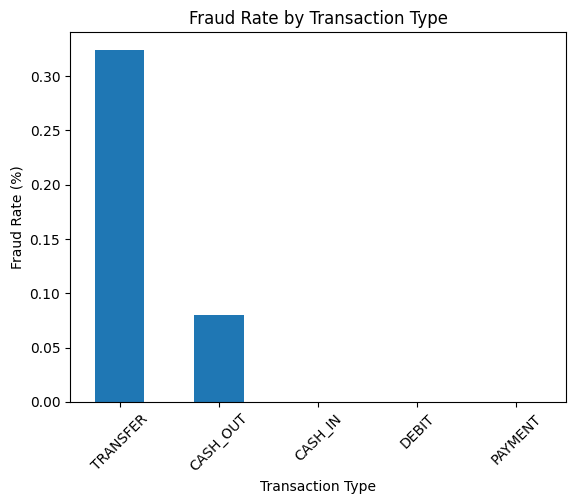

In [48]:
fraud_by_type["fraud_rate_percent"].sort_values(ascending=False).plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [49]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0.0,355224.0,174156.797291,2.896284e+05,0.3,13172.735,80479.725,231627.78,6419835.27
1.0,197.0,750186.830812,1.509184e+06,119.0,18627.020,93810.760,747282.40,10000000.00


In [50]:
df.groupby("isFraud")["amount"].median()

,amount
isFraud,
0.0,80479.725
1.0,93810.760


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

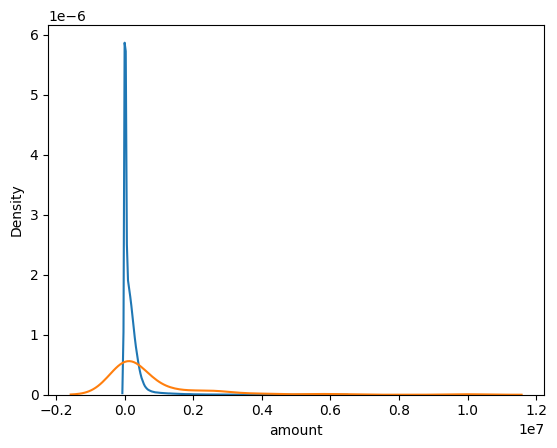

In [51]:
#plot amount KDE
sns.kdeplot(df.loc[df["isFraud"] == 0, "amount"], label="Non-Fraud")
sns.kdeplot(df.loc[df["isFraud"] == 1, "amount"], label="Fraud")
plt

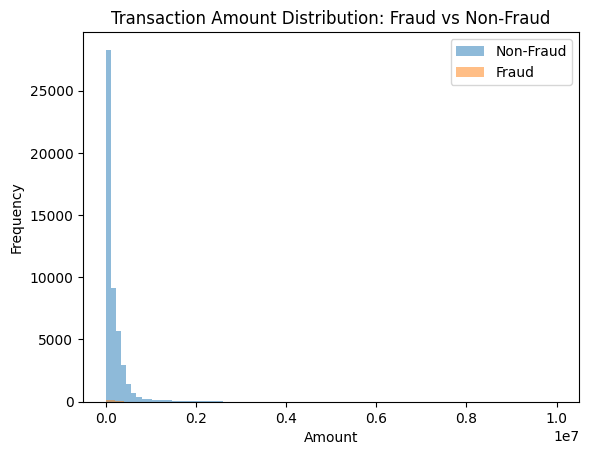

In [52]:
df[df["isFraud"] == 0]["amount"].sample(50000, random_state=42).plot(
    kind="hist", bins=50, alpha=0.5, label="Non-Fraud"
)

df[df["isFraud"] == 1]["amount"].plot(
    kind="hist", bins=50, alpha=0.5, label="Fraud"
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

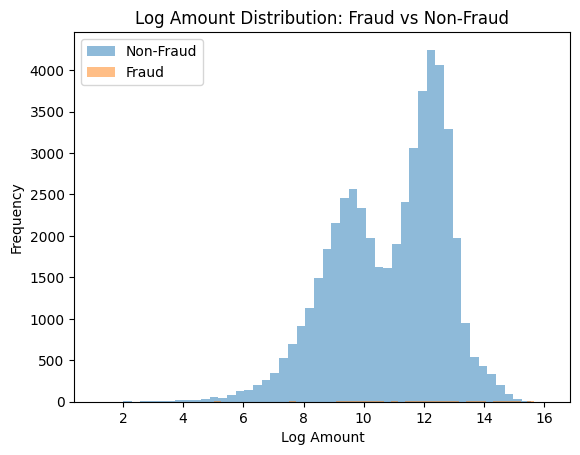

In [53]:
df["log_amount"] = np.log1p(df["amount"])

df[df["isFraud"] == 0]["log_amount"].sample(50000, random_state=42).plot(
    kind="hist", bins=50, alpha=0.5, label="Non-Fraud"
)

df[df["isFraud"] == 1]["log_amount"].plot(
    kind="hist", bins=50, alpha=0.5, label="Fraud"
)

plt.title("Log Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [54]:
df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

df["orig_amount_error"] = df["amount"] - df["orig_balance_diff"]
df["dest_amount_error"] = df["amount"] - df["dest_balance_diff"]

In [55]:
df.groupby("isFraud")[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "orig_balance_diff",
    "orig_amount_error",
    "oldbalanceDest",
    "newbalanceDest",
    "dest_balance_diff",
    "dest_amount_error"
]].mean()

,amount,oldbalanceOrg,newbalanceOrig,orig_balance_diff,orig_amount_error,oldbalanceDest,newbalanceDest,dest_balance_diff,dest_amount_error
isFraud,,,,,,,,,
0.0,174156.797291,891028.180196,910641.849922,-19613.669726,193770.467017,984463.550528,1.191399e+06,206935.336881,-32778.53959
1.0,750186.830812,741820.895838,17123.533553,724697.362284,25489.468528,312339.309543,8.103720e+05,498032.733503,252154.09731


In [56]:
df["orig_zero_balance_after"] = (df["newbalanceOrig"] == 0).astype(int)

pd.crosstab(df["orig_zero_balance_after"], df["isFraud"])

isFraud,0.0,1.0
orig_zero_balance_after,,
0,159417,2
1,195807,195


In [57]:
zero_balance_analysis = df.groupby("orig_zero_balance_after")["isFraud"].agg(
    total="count",
    frauds="sum"
)

zero_balance_analysis["fraud_rate_percent"] = (
    zero_balance_analysis["frauds"] / zero_balance_analysis["total"]
) * 100

zero_balance_analysis

,total,frauds,fraud_rate_percent
orig_zero_balance_after,,,
0,159419,2.0,0.001255
1,196002,195.0,0.099489


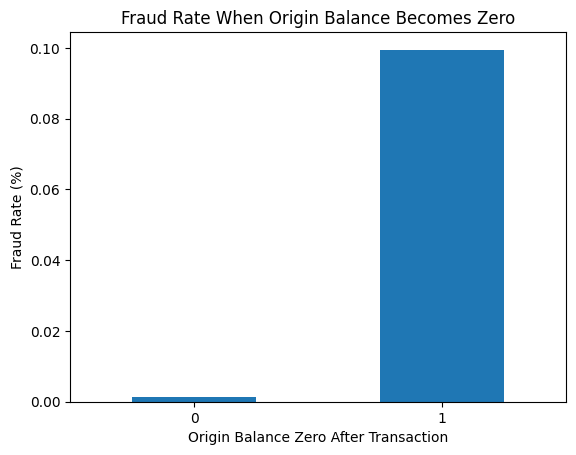

In [58]:
zero_balance_analysis["fraud_rate_percent"].plot(kind="bar")
plt.title("Fraud Rate When Origin Balance Becomes Zero")
plt.xlabel("Origin Balance Zero After Transaction")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [59]:
df["amount_equals_oldbalance"] = (
    df["amount"] == df["oldbalanceOrg"]
).astype(int)

pd.crosstab(df["amount_equals_oldbalance"], df["isFraud"])

isFraud,0.0,1.0
amount_equals_oldbalance,,
0,355224,14
1,0,183


In [60]:
amount_balance_analysis = df.groupby("amount_equals_oldbalance")["isFraud"].agg(
    total="count",
    frauds="sum"
)

amount_balance_analysis["fraud_rate_percent"] = (
    amount_balance_analysis["frauds"] / amount_balance_analysis["total"]
) * 100

amount_balance_analysis

,total,frauds,fraud_rate_percent
amount_equals_oldbalance,,,
0,355238,14.0,0.003941
1,183,183.0,100.000000


In [61]:

df["amount_to_oldbalance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

In [62]:
df.groupby("isFraud")["amount_to_oldbalance_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0.0,355224.0,58772.658701,192526.460939,5.012203e-07,0.163265,5.872987,12240.227500,5677662.29
1.0,197.0,24617.100004,165298.402779,6.918552e-01,0.999942,0.999989,0.999999,1933920.80


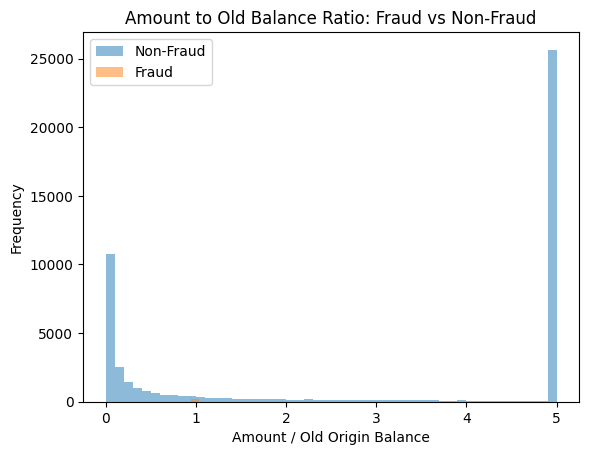

In [63]:
df["amount_to_oldbalance_ratio_capped"] = df["amount_to_oldbalance_ratio"].clip(upper=5)

df[df["isFraud"] == 0]["amount_to_oldbalance_ratio_capped"].sample(50000, random_state=42).plot(
    kind="hist", bins=50, alpha=0.5, label="Non-Fraud"
)

df[df["isFraud"] == 1]["amount_to_oldbalance_ratio_capped"].plot(
    kind="hist", bins=50, alpha=0.5, label="Fraud"
)

plt.title("Amount to Old Balance Ratio: Fraud vs Non-Fraud")
plt.xlabel("Amount / Old Origin Balance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

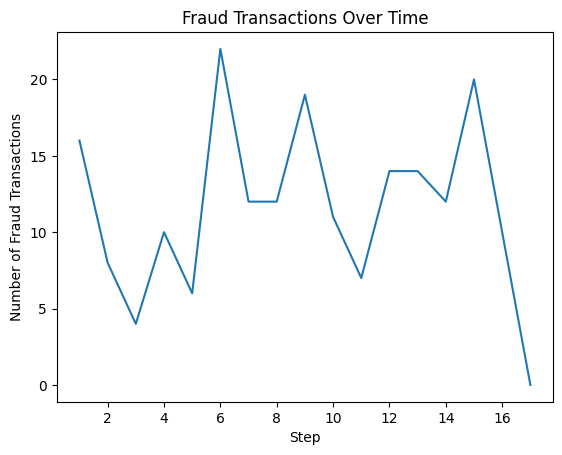

In [64]:
#fraud over time
fraud_over_time = df.groupby("step")["isFraud"].sum()

fraud_over_time.plot()
plt.title("Fraud Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")
plt.show()

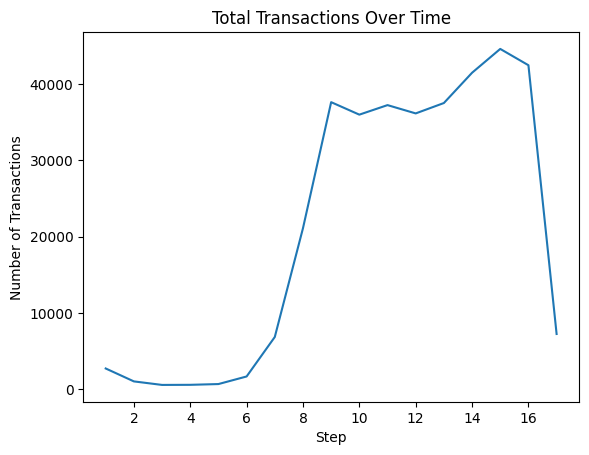

In [65]:
#total transaction over time
transactions_over_time = df.groupby("step")["isFraud"].count()

transactions_over_time.plot()
plt.title("Total Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")
plt.show()

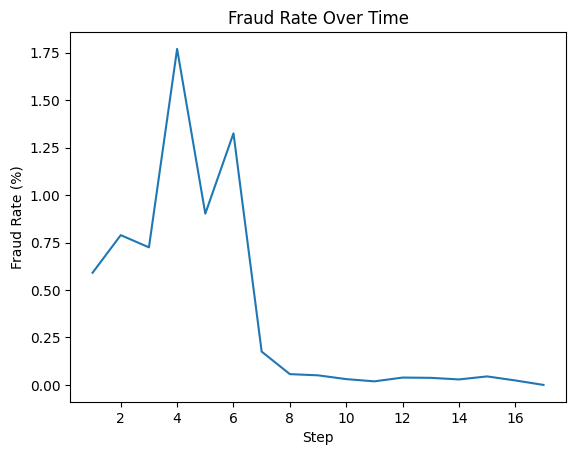

In [66]:
#fraud rate over time
fraud_rate_over_time = (
    df.groupby("step")["isFraud"].sum() / df.groupby("step")["isFraud"].count()
) * 100

fraud_rate_over_time.plot()
plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")
plt.show()

In [67]:
print("Unique senders:", df["nameOrig"].nunique())
print("Unique receivers:", df["nameDest"].nunique())

Unique senders: 355400
Unique receivers: 157246


In [68]:
df["nameDest"].value_counts().head(10)

,count
nameDest,
C1286084959,86
C985934102,85
C248609774,83
C665576141,80
C2083562754,79
C1590550415,76
C977993101,76
C1360767589,74
C451111351,72


In [69]:
df[df["isFraud"] == 1]["nameDest"].value_counts().head(10)

,count
nameDest,
C410033330,2
C200064275,2
C38997010,1
C972765878,1
C1007251739,1
C339924917,1
C1848415041,1
C431687661,1
C716083600,1


In [70]:
df[df["isFraud"] == 1]["nameOrig"].value_counts().head(5)

,count
nameOrig,
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1


In [71]:
#correlation analysis
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[numeric_cols].corr()

corr["isFraud"].sort_values(ascending=False)

,isFraud
isFraud,1.000000
amount_equals_oldbalance,0.963793
orig_balance_diff,0.136614
amount,0.046427
orig_zero_balance_after,0.020758
dest_amount_error,0.010862
dest_balance_diff,0.009806
log_amount,0.006494
oldbalanceOrg,-0.001206
newbalanceDest,-0.003485


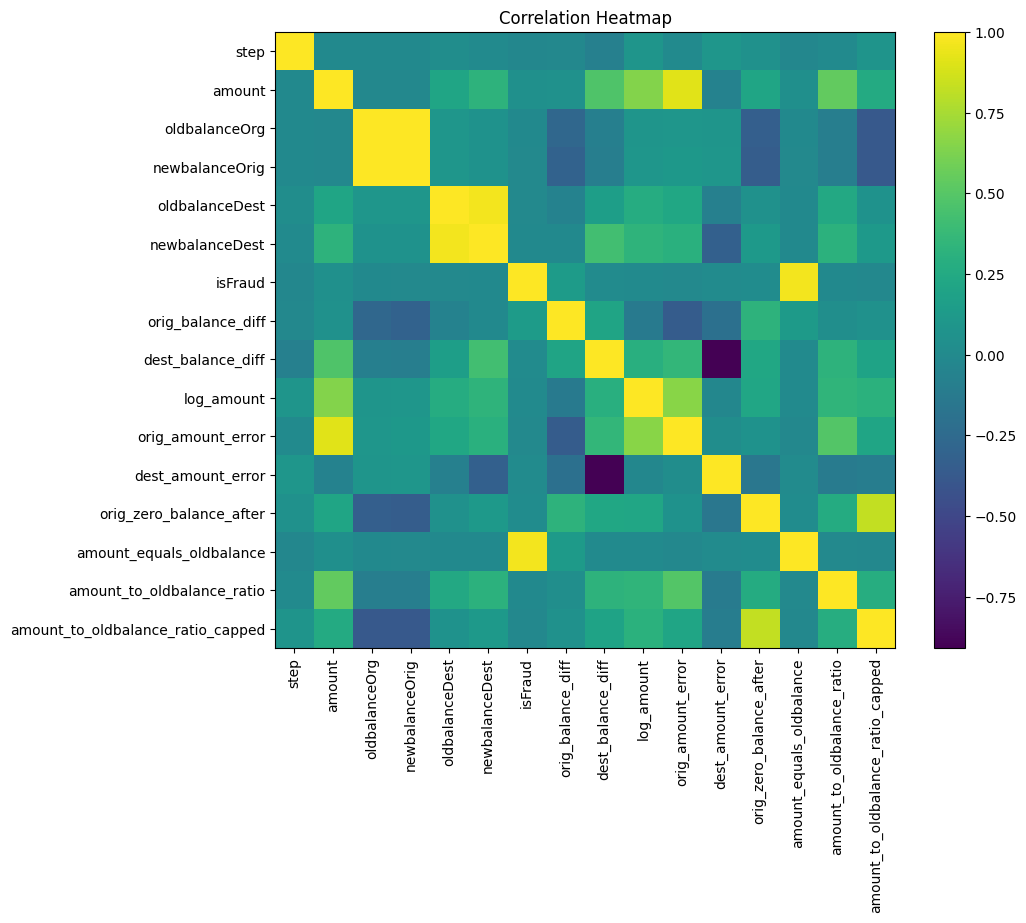

In [74]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

**Observations**
1. The dataset is highly imbalanced, with fraud transactions forming a very small percentage of total transactions.

2. Fraud transactions are concentrated in specific transaction types, especially TRANSFER and CASH_OUT.

3. Transaction amount is an important feature because fraud transactions show different amount patterns compared to normal transactions.

4. Balance-related columns are strongly connected, so balance-difference features were created.

5. Transactions where the origin account balance becomes zero after the transaction may indicate suspicious behavior.

6. The column isFlaggedFraud contains only zero values, so it was removed from model training.

7. Engineered features such as orig_balance_diff, orig_amount_error, amount_to_oldbalance_ratio, and orig_zero_balance_after can help the model detect abnormal transaction behavior.

**STEP 3 : Preprocess Data**

1. Copy original data
2. Remove useless columns
3. Handle missing values and duplicates
4. Encode categorical column
5. Separate X and y
6. Train-test split
7. Handle class imbalance carefully

In [75]:
df_clean = df.copy()

In [77]:
df_clean = df_clean.drop(columns=["nameOrig", "nameDest"])

In [78]:
df_clean.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
orig_balance_diff,0
dest_balance_diff,0


In [80]:
df[df_clean.duplicated()]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,log_amount,orig_amount_error,dest_amount_error,orig_zero_balance_after,amount_equals_oldbalance,amount_to_oldbalance_ratio,amount_to_oldbalance_ratio_capped
11104,7,PAYMENT,1849.50,C176119823,0.0,0.0,M924365923,0.0,0.0,0.0,0.0,0.0,7.523211,1849.50,1849.50,1,0,1849.50,5.0
33556,8,PAYMENT,7759.31,C894383363,0.0,0.0,M795767038,0.0,0.0,0.0,0.0,0.0,8.956778,7759.31,7759.31,1,0,7759.31,5.0
59969,9,PAYMENT,2388.93,C779916076,0.0,0.0,M1832401647,0.0,0.0,0.0,0.0,0.0,7.779019,2388.93,2388.93,1,0,2388.93,5.0
60763,9,PAYMENT,10042.85,C596036223,0.0,0.0,M1506828640,0.0,0.0,0.0,0.0,0.0,9.214716,10042.85,10042.85,1,0,10042.85,5.0
63096,9,PAYMENT,2783.83,C1239643439,0.0,0.0,M1927563175,0.0,0.0,0.0,0.0,0.0,7.931942,2783.83,2783.83,1,0,2783.83,5.0
69138,9,PAYMENT,6755.57,C1117274221,0.0,0.0,M482927394,0.0,0.0,0.0,0.0,0.0,8.818271,6755.57,6755.57,1,0,6755.57,5.0
72575,9,PAYMENT,6499.28,C1157625924,0.0,0.0,M62308125,0.0,0.0,0.0,0.0,0.0,8.779601,6499.28,6499.28,1,0,6499.28,5.0
105715,10,PAYMENT,3237.54,C1825261475,0.0,0.0,M2123766175,0.0,0.0,0.0,0.0,0.0,8.082878,3237.54,3237.54,1,0,3237.54,5.0
120246,11,PAYMENT,2041.31,C1969823404,0.0,0.0,M691871476,0.0,0.0,0.0,0.0,0.0,7.621837,2041.31,2041.31,1,0,2041.31,5.0
131202,11,PAYMENT,2082.03,C985616339,0.0,0.0,M1734347832,0.0,0.0,0.0,0.0,0.0,7.641579,2082.03,2082.03,1,0,2082.03,5.0


In [81]:
df_clean = df_clean.drop_duplicates()

In [82]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 355388 entries, 0 to 355420
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   step                               355388 non-null  int64  
 1   type                               355388 non-null  object 
 2   amount                             355388 non-null  float64
 3   oldbalanceOrg                      355388 non-null  float64
 4   newbalanceOrig                     355388 non-null  float64
 5   oldbalanceDest                     355388 non-null  float64
 6   newbalanceDest                     355388 non-null  float64
 7   isFraud                            355388 non-null  float64
 8   orig_balance_diff                  355388 non-null  float64
 9   dest_balance_diff                  355388 non-null  float64
 10  log_amount                         355388 non-null  float64
 11  orig_amount_error                  355388 no

In [83]:
df_clean["isFraud"] = df_clean["isFraud"].astype(int)

In [84]:
df_clean["isFraud"].value_counts()

,count
isFraud,
0,355191
1,197


In [85]:
df_clean = pd.get_dummies(df_clean, columns=["type"], drop_first=True)

In [86]:
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 355388 entries, 0 to 355420
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   step                               355388 non-null  int64  
 1   amount                             355388 non-null  float64
 2   oldbalanceOrg                      355388 non-null  float64
 3   newbalanceOrig                     355388 non-null  float64
 4   oldbalanceDest                     355388 non-null  float64
 5   newbalanceDest                     355388 non-null  float64
 6   isFraud                            355388 non-null  int64  
 7   orig_balance_diff                  355388 non-null  float64
 8   dest_balance_diff                  355388 non-null  float64
 9   log_amount                         355388 non-null  float64
 10  orig_amount_error                  355388 non-null  float64
 11  dest_amount_error                  355388 no

In [87]:
df_clean = df_clean.drop(columns=["amount_to_oldbalance_ratio_capped"])

In [88]:
X = df_clean.drop(columns=["isFraud"])
y = df_clean["isFraud"]

In [89]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (355388, 18)
y shape: (355388,)


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [91]:
print("Train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Test distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train distribution:
isFraud
0    99.944427
1     0.055573
Name: proportion, dtype: float64
Test distribution:
isFraud
0    99.945131
1     0.054869
Name: proportion, dtype: float64


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**STEP 4 : Train Baseline Model**

Train a simple model
Evaluate fraud detection performance
Understand precision, recall, F1-score
Check confusion matrix

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [94]:
class_weight="balanced"

In [95]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [96]:
y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

Accuracy: 0.9906722192520893
Precision: 0.05172413793103448
Recall: 0.9230769230769231
F1 Score: 0.09795918367346938
ROC-AUC: 0.9837943838000145
PR-AUC: 0.9002967656694663


In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     71039
           1       0.05      0.92      0.10        39

    accuracy                           0.99     71078
   macro avg       0.53      0.96      0.55     71078
weighted avg       1.00      0.99      0.99     71078



In [99]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[70379   660]
 [    3    36]]


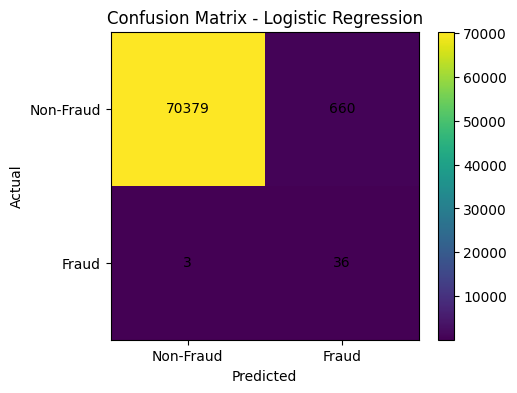

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.yticks([0, 1], ["Non-Fraud", "Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

The Logistic Regression baseline achieved high recall, meaning it detected most fraud transactions. However, the precision was low, indicating a high number of false positives. Therefore, threshold tuning and advanced models are required to improve the balance between fraud detection and false alarms.

In [101]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print("Threshold:", threshold)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("-" * 40)

Threshold: 0.3
Precision: 0.03183023872679045
Recall: 0.9230769230769231
F1 Score: 0.06153846153846154
----------------------------------------
Threshold: 0.5
Precision: 0.05172413793103448
Recall: 0.9230769230769231
F1 Score: 0.09795918367346938
----------------------------------------
Threshold: 0.6
Precision: 0.06557377049180328
Recall: 0.9230769230769231
F1 Score: 0.12244897959183673
----------------------------------------
Threshold: 0.7
Precision: 0.08801955990220049
Recall: 0.9230769230769231
F1 Score: 0.16071428571428573
----------------------------------------
Threshold: 0.8
Precision: 0.13725490196078433
Recall: 0.8974358974358975
F1 Score: 0.23809523809523808
----------------------------------------
Threshold: 0.9
Precision: 0.3181818181818182
Recall: 0.8974358974358975
F1 Score: 0.4697986577181208
----------------------------------------


In [102]:
#find best threshold autometically
import pandas as pd
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1_score"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
) / (threshold_df["precision"] + threshold_df["recall"])

threshold_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
71043,1.000000,1.000000,0.897436,0.945946
71042,0.999939,0.972222,0.897436,0.933333
71041,0.999846,0.945946,0.897436,0.921053
71040,0.999738,0.921053,0.897436,0.909091
71039,0.999041,0.897436,0.897436,0.897436
71038,0.997235,0.875000,0.897436,0.886076
71037,0.990546,0.853659,0.897436,0.875000
71036,0.989522,0.833333,0.897436,0.864198
71035,0.989394,0.813953,0.897436,0.853659
71034,0.987931,0.795455,0.897436,0.843373


In [103]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[70379   660]
 [    3    36]]


In [104]:
pd.set_option("display.float_format", "{:.10f}".format)

threshold_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
71043,1.0000000000,1.0000000000,0.8974358974,0.9459459459
71042,0.9999388570,0.9722222222,0.8974358974,0.9333333333
71041,0.9998459053,0.9459459459,0.8974358974,0.9210526316
71040,0.9997383851,0.9210526316,0.8974358974,0.9090909091
71039,0.9990406776,0.8974358974,0.8974358974,0.8974358974
71038,0.9972352001,0.8750000000,0.8974358974,0.8860759494
71037,0.9905459454,0.8536585366,0.8974358974,0.8750000000
71036,0.9895221441,0.8333333333,0.8974358974,0.8641975309
71035,0.9893943464,0.8139534884,0.8974358974,0.8536585366
71034,0.9879309975,0.7954545455,0.8974358974,0.8433734940


In [105]:
best_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("F1 Score:", best_row["f1_score"])

Best Threshold: 1.0
Precision: 1.0
Recall: 0.8974358974358975
F1 Score: 0.945945945945946


In [106]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)

In [107]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       1.00      0.90      0.95        39

    accuracy                           1.00     71078
   macro avg       1.00      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078

[[71039     0]
 [    4    35]]


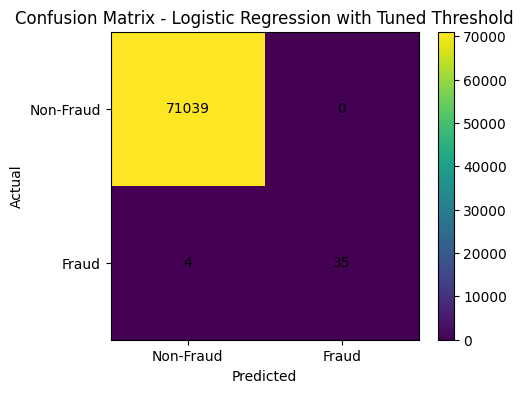

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm_tuned)
plt.title("Confusion Matrix - Logistic Regression with Tuned Threshold")
plt.colorbar()

plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.yticks([0, 1], ["Non-Fraud", "Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_tuned[i, j], ha="center", va="center")

plt.show()

In [109]:
import pandas as pd

score_check = pd.DataFrame({
    "actual": y_test,
    "fraud_probability": y_proba
})

print("Max non-fraud probability:")
print(score_check[score_check["actual"] == 0]["fraud_probability"].max())

print("Min fraud probability:")
print(score_check[score_check["actual"] == 1]["fraud_probability"].min())

print("Fraud probability summary:")
print(score_check.groupby("actual")["fraud_probability"].describe())

Max non-fraud probability:
0.9999388569846566
Min fraud probability:
3.321397908112676e-06
Fraud probability summary:
                  count         mean          std          min          25%  \
actual                                                                        
0      71039.0000000000 0.0177648249 0.0832220634 0.0000000000 0.0000000000   
1         39.0000000000 0.9167582899 0.2699572173 0.0000033214 1.0000000000   

                50%          75%          max  
actual                                         
0      0.0000000000 0.0000138592 0.9999388570  
1      1.0000000000 1.0000000000 1.0000000000  


In [110]:
print([col for col in X.columns if "fraud" in col.lower()])

[]


In [111]:
assert "isFraud" not in X.columns
assert "isFlaggedFraud" not in X.columns

**Step 5 : Advanced Model**

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [113]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [114]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [115]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("PR-AUC:", average_precision_score(y_test, rf_proba))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9999437237963927
Precision: 1.0
Recall: 0.8974358974358975
F1 Score: 0.9459459459459459
ROC-AUC: 0.9486479257872436
PR-AUC: 0.8974921736395047

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       1.00      0.90      0.95        39

    accuracy                           1.00     71078
   macro avg       1.00      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078


Confusion Matrix:
[[71039     0]
 [    4    35]]


In [116]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
12,amount_equals_oldbalance,0.2519616872
9,orig_amount_error,0.2102981235
13,amount_to_oldbalance_ratio,0.1338647263
6,orig_balance_diff,0.0810247930
3,newbalanceOrig,0.0730540322
11,orig_zero_balance_after,0.0703492580
0,step,0.0251865399
17,type_TRANSFER,0.0225305358
4,oldbalanceDest,0.0222878691
2,oldbalanceOrg,0.0214823624


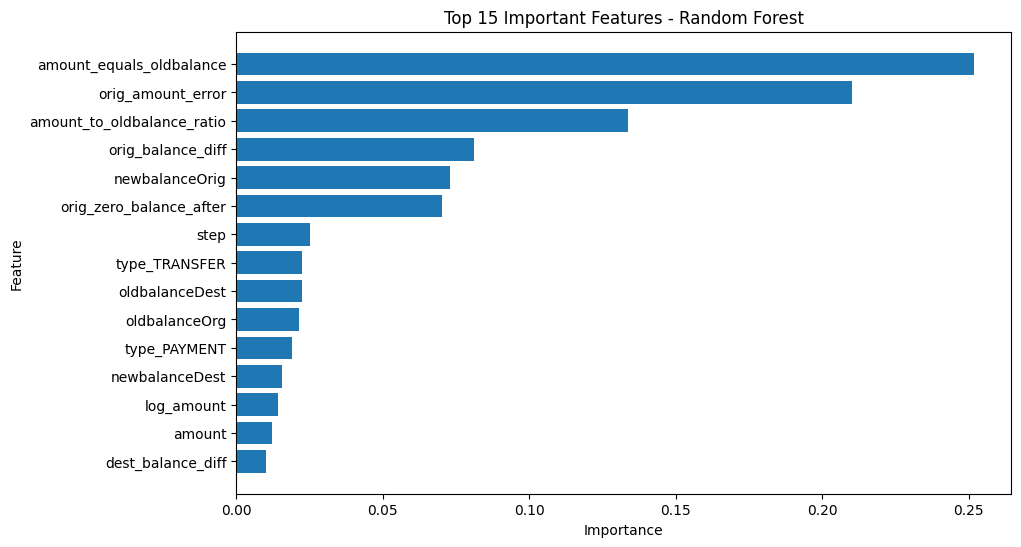

In [117]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [118]:
from xgboost import XGBClassifier

In [119]:
non_fraud = y_train.value_counts()[0]
fraud = y_train.value_counts()[1]

scale_pos_weight = non_fraud / fraud

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 1798.4303797468353


In [120]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [121]:
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [122]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("PR-AUC:", average_precision_score(y_test, xgb_proba))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.9999296547454909
Precision: 0.9722222222222222
Recall: 0.8974358974358975
F1 Score: 0.9333333333333333
ROC-AUC: 0.9817186009418446
PR-AUC: 0.9127877263890994

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       0.97      0.90      0.93        39

    accuracy                           1.00     71078
   macro avg       0.99      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078


Confusion Matrix:
[[71038     1]
 [    4    35]]


In [123]:
def evaluate_model(model_name, y_test, y_pred, y_proba):
    print(f"Model: {model_name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC:", average_precision_score(y_test, y_proba))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [124]:
evaluate_model("Random Forest", y_test, rf_pred, rf_proba)
evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)

Model: Random Forest
----------------------------------------
Accuracy: 0.9999437237963927
Precision: 1.0
Recall: 0.8974358974358975
F1 Score: 0.9459459459459459
ROC-AUC: 0.9486479257872436
PR-AUC: 0.8974921736395047

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       1.00      0.90      0.95        39

    accuracy                           1.00     71078
   macro avg       1.00      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078


Confusion Matrix:
[[71039     0]
 [    4    35]]
Model: XGBoost
----------------------------------------
Accuracy: 0.9999296547454909
Precision: 0.9722222222222222
Recall: 0.8974358974358975
F1 Score: 0.9333333333333333
ROC-AUC: 0.9817186009418446
PR-AUC: 0.9127877263890994

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       0.97

In [125]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, rf_proba),
        average_precision_score(y_test, xgb_proba)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9906722193,0.0517241379,0.9230769231,0.0979591837,0.9837943838,0.9002967657
1,Random Forest,0.9999437238,1.0000000000,0.8974358974,0.9459459459,0.9486479258,0.8974921736
2,XGBoost,0.9999296547,0.9722222222,0.8974358974,0.9333333333,0.9817186009,0.9127877264


Three models were trained and compared: Logistic Regression, Random Forest, and XGBoost. Logistic Regression was used as the baseline model. Although it achieved high recall, its precision was very low, meaning it produced many false positives.

Random Forest and XGBoost performed significantly better. Random Forest achieved the highest F1-score, while XGBoost achieved the highest PR-AUC, indicating better ranking performance on the imbalanced fraud dataset.

Since fraud detection requires both strong classification and reliable probability ranking, XGBoost was selected as the final model for further threshold tuning and deployment.

In [126]:
assert "isFraud" not in X.columns
assert "isFlaggedFraud" not in X.columns

In [127]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1_score"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
) / (
    threshold_df["precision"] + threshold_df["recall"]
)

threshold_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
35081,0.9999287128,1.0000000000,0.8974358974,0.9459459459
35080,0.7829023600,0.9722222222,0.8974358974,0.9333333333
35082,0.9999581575,1.0000000000,0.8717948718,0.9315068493
35079,0.4197984934,0.9459459459,0.8974358974,0.9210526316
35083,0.9999653101,1.0000000000,0.8461538462,0.9166666667
35078,0.2100519091,0.9210526316,0.8974358974,0.9090909091
35084,0.9999669790,1.0000000000,0.8205128205,0.9014084507
35077,0.1103883684,0.8974358974,0.8974358974,0.8974358974
35076,0.1059919223,0.8750000000,0.8974358974,0.8860759494
35085,0.9999748468,1.0000000000,0.7948717949,0.8857142857


In [128]:
best_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("F1 Score:", best_row["f1_score"])

Best Threshold: 0.9999287128448486
Precision: 1.0
Recall: 0.8974358974358975
F1 Score: 0.945945945945946


In [129]:
xgb_pred_tuned = (xgb_proba >= best_threshold).astype(int)

In [130]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, xgb_pred_tuned))
print(confusion_matrix(y_test, xgb_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       1.00      0.90      0.95        39

    accuracy                           1.00     71078
   macro avg       1.00      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078

[[71039     0]
 [    4    35]]


In [131]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.0 MB/s eta 0:00:00


In [132]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

# Split train into train + validation
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

def objective(trial):
    non_fraud = y_train_opt.value_counts()[0]
    fraud = y_train_opt.value_counts()[1]
    scale_pos_weight = non_fraud / fraud

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)
    model.fit(X_train_opt, y_train_opt)

    val_proba = model.predict_proba(X_val)[:, 1]

    pr_auc = average_precision_score(y_val, val_proba)

    return pr_auc

In [133]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best PR-AUC:", study.best_value)
print("Best Parameters:")
print(study.best_params)

[I 2026-05-24 07:32:01,663] A new study created in memory with name: no-name-99be270e-9e57-46e6-ab19-ad845810ee34
[I 2026-05-24 07:32:09,952] Trial 0 finished with value: 0.8655137967764349 and parameters: {'n_estimators': 468, 'max_depth': 3, 'learning_rate': 0.1476273024317952, 'subsample': 0.8468063483573862, 'colsample_bytree': 0.7214819880755114, 'min_child_weight': 10, 'gamma': 0.6175332016315521, 'reg_alpha': 0.20008611513492147, 'reg_lambda': 1.5774640029693692}. Best is trial 0 with value: 0.8655137967764349.
[I 2026-05-24 07:32:16,026] Trial 1 finished with value: 0.8544536662386555 and parameters: {'n_estimators': 322, 'max_depth': 4, 'learning_rate': 0.1071236628843049, 'subsample': 0.7454511012626148, 'colsample_bytree': 0.9065369708384093, 'min_child_weight': 1, 'gamma': 0.44396298087476915, 'reg_alpha': 4.939017720907109, 'reg_lambda': 4.11496136151231}. Best is trial 0 with value: 0.8655137967764349.
[I 2026-05-24 07:32:24,646] Trial 2 finished with value: 0.84725562291

Best PR-AUC: 0.8754226822172807
Best Parameters:
{'n_estimators': 313, 'max_depth': 8, 'learning_rate': 0.174329853043439, 'subsample': 0.9938158903621768, 'colsample_bytree': 0.6899771998981526, 'min_child_weight': 8, 'gamma': 4.064882042554316, 'reg_alpha': 2.616898824635902, 'reg_lambda': 0.974326262099785}


In [134]:
best_params = study.best_params

non_fraud = y_train.value_counts()[0]
fraud = y_train.value_counts()[1]
scale_pos_weight = non_fraud / fraud

best_params["scale_pos_weight"] = scale_pos_weight
best_params["eval_metric"] = "logloss"
best_params["random_state"] = 42
best_params["n_jobs"] = -1

xgb_tuned = XGBClassifier(**best_params)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6899771998981526, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=4.064882042554316, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.174329853043439,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=313, n_jobs=-1,
              num_parallel_tree=None, ...)

In [135]:
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_proba = xgb_tuned.predict_proba(X_test)[:, 1]

In [136]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score

print("Accuracy:", accuracy_score(y_test, xgb_tuned_pred))
print("Precision:", precision_score(y_test, xgb_tuned_pred))
print("Recall:", recall_score(y_test, xgb_tuned_pred))
print("F1 Score:", f1_score(y_test, xgb_tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_tuned_proba))
print("PR-AUC:", average_precision_score(y_test, xgb_tuned_proba))

print(classification_report(y_test, xgb_tuned_pred))
print(confusion_matrix(y_test, xgb_tuned_pred))

Accuracy: 0.999915585694589
Precision: 0.9459459459459459
Recall: 0.8974358974358975
F1 Score: 0.9210526315789473
ROC-AUC: 0.9693534176423857
PR-AUC: 0.9186664425297291
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       0.95      0.90      0.92        39

    accuracy                           1.00     71078
   macro avg       0.97      0.95      0.96     71078
weighted avg       1.00      1.00      1.00     71078

[[71037     2]
 [    4    35]]


In [137]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

precision, recall, thresholds = precision_recall_curve(
    y_test,
    xgb_tuned_proba
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1_score"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
) / (
    threshold_df["precision"] + threshold_df["recall"]
)

threshold_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
7573,0.9999530315,1.0000000000,0.8974358974,0.9459459459
7572,0.9379890561,0.9722222222,0.8974358974,0.9333333333
7574,0.9999586344,1.0000000000,0.8717948718,0.9315068493
7571,0.5585431457,0.9459459459,0.8974358974,0.9210526316
7575,0.9999597073,1.0000000000,0.8461538462,0.9166666667
7570,0.4444924891,0.9210526316,0.8974358974,0.9090909091
7576,0.9999635220,1.0000000000,0.8205128205,0.9014084507
7569,0.4165758491,0.8974358974,0.8974358974,0.8974358974
7568,0.3873597383,0.8750000000,0.8974358974,0.8860759494
7577,0.9999638796,1.0000000000,0.7948717949,0.8857142857


In [138]:
best_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("F1 Score:", best_row["f1_score"])

Best Threshold: 0.999953031539917
Precision: 1.0
Recall: 0.8974358974358975
F1 Score: 0.945945945945946


In [139]:
from sklearn.metrics import classification_report, confusion_matrix

xgb_tuned_pred_threshold = (xgb_tuned_proba >= best_threshold).astype(int)

print(classification_report(y_test, xgb_tuned_pred_threshold))
print(confusion_matrix(y_test, xgb_tuned_pred_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71039
           1       1.00      0.90      0.95        39

    accuracy                           1.00     71078
   macro avg       1.00      0.95      0.97     71078
weighted avg       1.00      1.00      1.00     71078

[[71039     0]
 [    4    35]]


**STEP 6 : Fraud Risk Decision System**

In [140]:
# ==============================
# Step 6: Fraud Risk Decision System
# ==============================

import pandas as pd
import numpy as np

# best_threshold should come from your threshold tuning step
# xgb_tuned_proba should be probability predictions from your tuned XGBoost model

block_threshold = best_threshold
review_threshold = 0.30

# 1. Decision function
def fraud_risk_decision(probability):
    if probability >= block_threshold:
        return "BLOCK"
    elif probability >= review_threshold:
        return "MANUAL_REVIEW"
    else:
        return "APPROVE"


# 2. Fraud reason function
def fraud_reasons(row):
    reasons = []

    if row["fraud_probability"] >= block_threshold:
        reasons.append("High ML fraud probability")

    if row["amount"] > amount_95th_percentile:
        reasons.append("High transaction amount")

    if row["newbalanceOrig"] == 0:
        reasons.append("Origin account balance became zero")

    if "amount_to_oldbalance_ratio" in row.index and row["amount_to_oldbalance_ratio"] > 0.9:
        reasons.append("Transaction amount close to origin balance")

    if "type_TRANSFER" in row.index and row["type_TRANSFER"] == 1:
        reasons.append("Transfer transaction type")

    if "type_CASH_OUT" in row.index and row["type_CASH_OUT"] == 1:
        reasons.append("Cash-out transaction type")

    if len(reasons) == 0:
        reasons.append("Low risk pattern")

    return ", ".join(reasons)


# 3. Create final results dataframe
final_results = X_test.copy()

final_results["actual_fraud"] = y_test.values
final_results["fraud_probability"] = xgb_tuned_proba

# 4. Calculate amount threshold for reason generation
amount_95th_percentile = X_test["amount"].quantile(0.95)

# 5. Apply decision system
final_results["risk_decision"] = final_results["fraud_probability"].apply(
    fraud_risk_decision
)

# 6. Add fraud reasons
final_results["fraud_reasons"] = final_results.apply(
    fraud_reasons,
    axis=1
)

# 7. Decision summary
decision_summary = final_results.groupby("risk_decision")["actual_fraud"].agg(
    total_transactions="count",
    fraud_transactions="sum"
)

decision_summary["fraud_rate_percent"] = (
    decision_summary["fraud_transactions"] /
    decision_summary["total_transactions"]
) * 100

# 8. High-risk transaction table
high_risk_transactions = final_results[
    [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "fraud_probability",
        "risk_decision",
        "actual_fraud",
        "fraud_reasons"
    ]
].sort_values(
    by="fraud_probability",
    ascending=False
)

# 9. Display outputs
print("Block Threshold:", block_threshold)
print("Review Threshold:", review_threshold)

print("\nDecision Distribution:")
print(final_results["risk_decision"].value_counts())

print("\nDecision Summary:")
display(decision_summary)

print("\nTop 20 High-Risk Transactions:")
display(high_risk_transactions.head(20))

Block Threshold: 0.999953031539917
Review Threshold: 0.3

Decision Distribution:
risk_decision
APPROVE          71038
BLOCK               35
MANUAL_REVIEW        5
Name: count, dtype: int64

Decision Summary:


,total_transactions,fraud_transactions,fraud_rate_percent
risk_decision,,,
APPROVE,71038,4,0.0056307892
BLOCK,35,35,100.0000000000
MANUAL_REVIEW,5,0,0.0000000000



Top 20 High-Risk Transactions:


,amount,oldbalanceOrg,newbalanceOrig,fraud_probability,risk_decision,actual_fraud,fraud_reasons
4775,86070.1700000000,86070.1700000000,0.0000000000,0.9999777079,BLOCK,1,"High ML fraud probability, Origin account bala..."
3683,18627.0200000000,18627.0200000000,0.0000000000,0.9999777079,BLOCK,1,"High ML fraud probability, Origin account bala..."
4104,10539.3700000000,10539.3700000000,0.0000000000,0.9999775887,BLOCK,1,"High ML fraud probability, Origin account bala..."
4693,13707.1100000000,13707.1100000000,0.0000000000,0.9999775887,BLOCK,1,"High ML fraud probability, Origin account bala..."
3271,14949.8400000000,14949.8400000000,0.0000000000,0.9999775887,BLOCK,1,"High ML fraud probability, Origin account bala..."
3,181.0000000000,181.0000000000,0.0000000000,0.9999775887,BLOCK,1,"High ML fraud probability, Origin account bala..."
7003,10224.0000000000,10224.0000000000,0.0000000000,0.9999775887,BLOCK,1,"High ML fraud probability, Origin account bala..."
2302,235238.6600000000,235238.6600000000,0.0000000000,0.9999769926,BLOCK,1,"High ML fraud probability, Origin account bala..."
34168,43092.0000000000,43092.0000000000,0.0000000000,0.9999758005,BLOCK,1,"High ML fraud probability, Origin account bala..."
10218,21729.0000000000,21729.0000000000,0.0000000000,0.9999758005,BLOCK,1,"High ML fraud probability, Origin account bala..."


,feature,importance
12,amount_equals_oldbalance,0.2694967389
11,orig_zero_balance_after,0.2130966038
3,newbalanceOrig,0.2110657543
9,orig_amount_error,0.1994672716
13,amount_to_oldbalance_ratio,0.0297201052
4,oldbalanceDest,0.0213566255
5,newbalanceDest,0.0088072289
6,orig_balance_diff,0.0085186511
10,dest_amount_error,0.0075138495
16,type_PAYMENT,0.0054602739


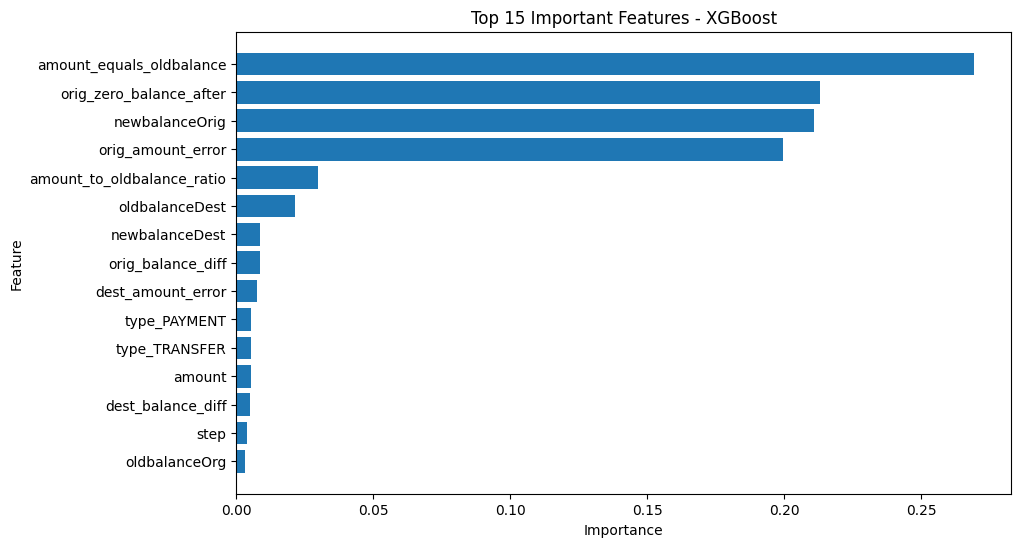

In [141]:
# ==============================
# Step 7A: Feature Importance
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(feature_importance.head(15))

# Plot top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

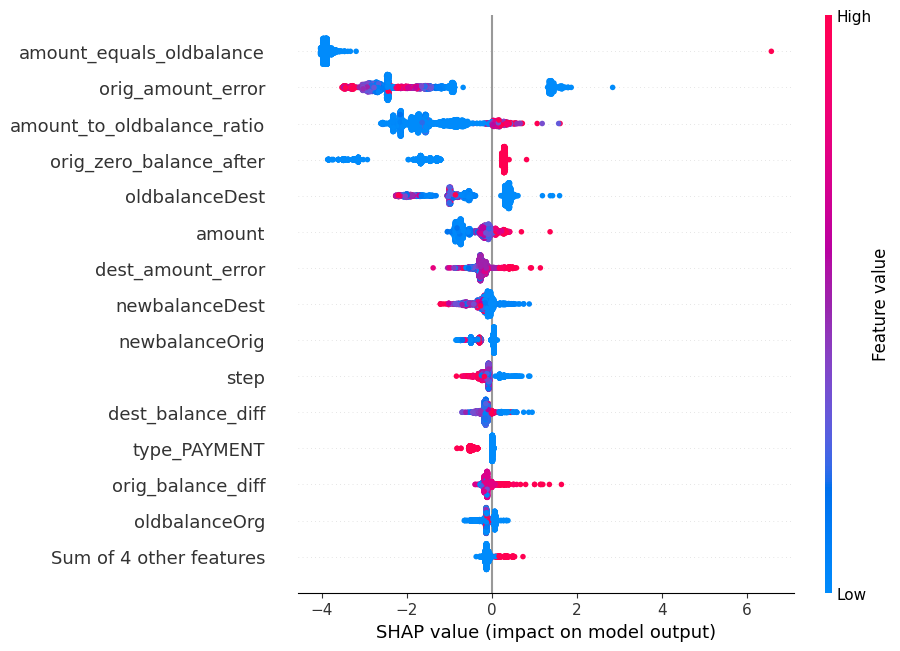

In [143]:
# ==============================
# Step 7B: SHAP Explainability
# ==============================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Use a sample to make SHAP faster
X_shap_sample = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_tuned)

# Calculate SHAP values
shap_values = explainer(X_shap_sample)

# Global SHAP summary plot
shap.plots.beeswarm(shap_values, max_display=15)

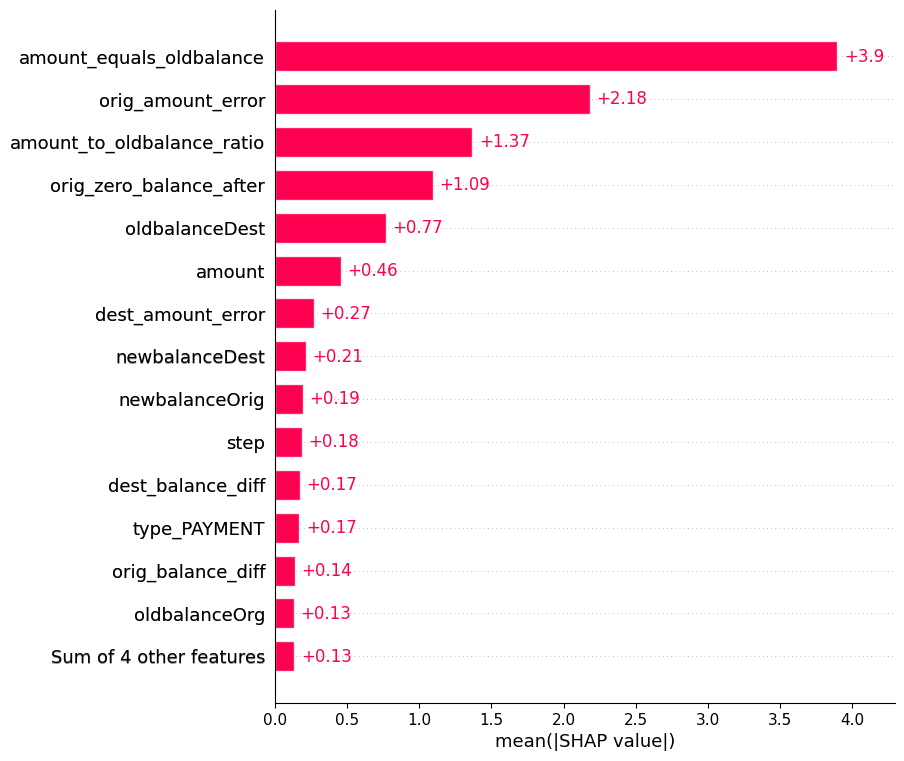

In [144]:
# Global feature importance using SHAP
shap.plots.bar(shap_values, max_display=15)

Fraud Probability:
0.9999777

Risk Decision:
BLOCK

Fraud Reasons:
High ML fraud probability, Origin account balance became zero, Transaction amount close to origin balance, Transfer transaction type


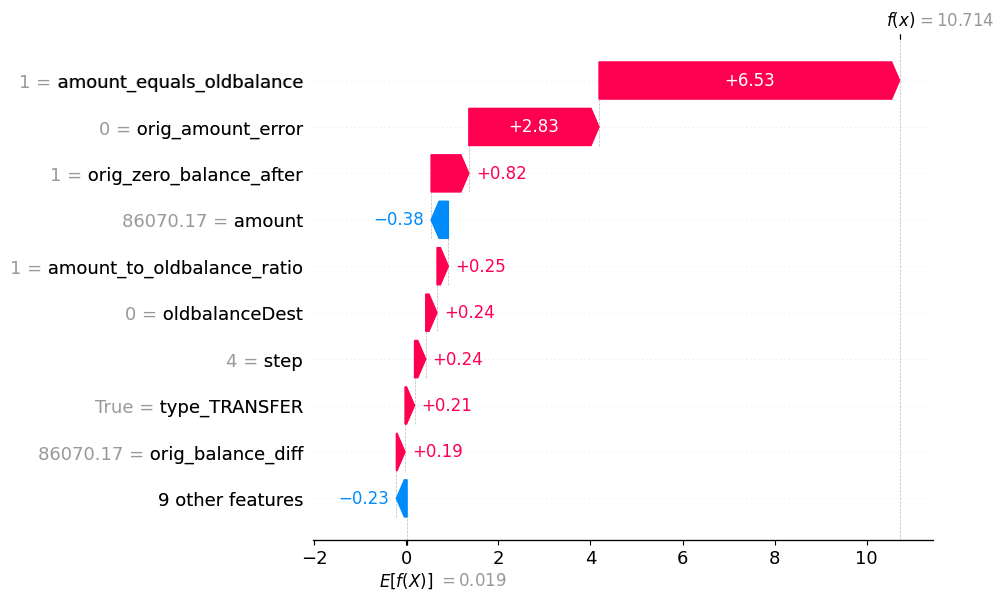

In [145]:
# Select the highest-risk transaction
top_transaction_index = high_risk_transactions.index[0]

single_transaction = X_test.loc[[top_transaction_index]]

# Calculate SHAP values for this transaction
single_shap_values = explainer(single_transaction)

print("Fraud Probability:")
print(final_results.loc[top_transaction_index, "fraud_probability"])

print("\nRisk Decision:")
print(final_results.loc[top_transaction_index, "risk_decision"])

print("\nFraud Reasons:")
print(final_results.loc[top_transaction_index, "fraud_reasons"])

# Local explanation plot
shap.plots.waterfall(single_shap_values[0], max_display=10)

In [146]:
# ==============================
# Step 7E: Readable Local Explanation
# ==============================

shap_df = pd.DataFrame({
    "feature": single_transaction.columns,
    "feature_value": single_transaction.iloc[0].values,
    "shap_impact": single_shap_values.values[0]
})

shap_df["abs_impact"] = shap_df["shap_impact"].abs()

shap_df = shap_df.sort_values(
    by="abs_impact",
    ascending=False
)

display(shap_df.head(10))

,feature,feature_value,shap_impact,abs_impact
12,amount_equals_oldbalance,1,6.5269751549,6.5269751549
9,orig_amount_error,0.0000000000,2.8261110783,2.8261110783
11,orig_zero_balance_after,1,0.8201888800,0.8201888800
1,amount,86070.1700000000,-0.3758388162,0.3758388162
13,amount_to_oldbalance_ratio,0.9999883817,0.2470318973,0.2470318973
4,oldbalanceDest,0.0000000000,0.2445175499,0.2445175499
0,step,4,0.2431598306,0.2431598306
17,type_TRANSFER,True,0.2062936276,0.2062936276
6,orig_balance_diff,86070.1700000000,0.1880897880,0.1880897880
10,dest_amount_error,86070.1700000000,-0.1571136713,0.1571136713


In [147]:
import joblib

joblib.dump(xgb_tuned, "xgb_fraud_model.pkl")
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']

In [148]:
final_results.to_csv("final_fraud_results.csv", index=False)
decision_summary.to_csv("decision_summary.csv")

The project successfully developed a digital payment fraud detection system using machine learning and rule-based risk decisioning. Multiple models were compared, including Logistic Regression, Random Forest, and XGBoost. The Optuna-tuned XGBoost model with threshold tuning was selected as the final model.

The final system not only predicts fraudulent transactions but also assigns each transaction into APPROVE, MANUAL_REVIEW, or BLOCK categories, making it suitable for real-world fraud monitoring workflows.